Install Libraries

In [ ]:
!pip install transformers datasets scikit-learn torch seaborn

Imports

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

Load Dataset

In [ ]:
dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]

train_data = train_data.shuffle(seed=42).select(range(15000))
test_data = test_data.shuffle(seed=42).select(range(5000))

Preprocessing

In [ ]:
train_data = train_data.filter(lambda x: x["text"] is not None)
test_data = test_data.filter(lambda x: x["text"] is not None)

Train / Validation Split

In [5]:
train_valid = train_data.train_test_split(test_size=0.1)

train_dataset = train_valid["train"]
val_dataset = train_valid["test"]

Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

Format for PyTorch

In [7]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Metrics

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="binary", zero_division=0
)
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True
)

Trainer

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Train Model

In [ ]:
trainer.train()

Evaluate Model

In [13]:
results = trainer.evaluate(test_data)
print("Test Results:", results)

Test Results: {'eval_loss': 0.2846790552139282, 'eval_accuracy': 0.8998, 'eval_precision': 0.8571428571428571, 'eval_recall': 0.960095770151636, 'eval_f1': 0.9057029926595144, 'eval_runtime': 78.6921, 'eval_samples_per_second': 63.539, 'eval_steps_per_second': 7.942, 'epoch': 2.0}


Confusion Matrix

Confusion Matrix:
 [[2093  401]
 [ 100 2406]]


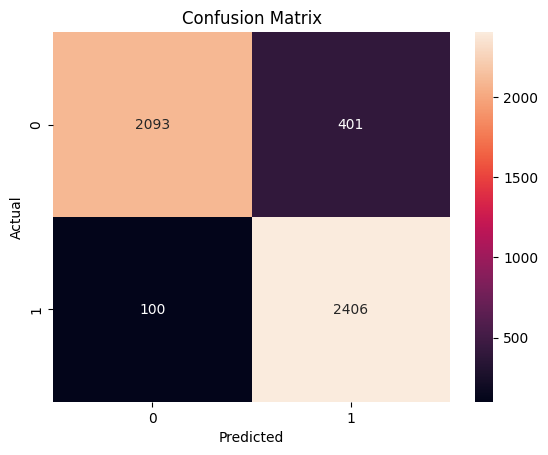

In [14]:
predictions = trainer.predict(test_data)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# plot
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Freeze BERT

In [ ]:
model_freeze = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

for param in model_freeze.bert.parameters():
    param.requires_grad = False

trainer_freeze = Trainer(
    model=model_freeze,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_freeze.train()

Evaluate Freeze

In [16]:
results_freeze = trainer_freeze.evaluate(test_data)
print("Freeze Model:", results_freeze)

Freeze Model: {'eval_loss': 0.668991208076477, 'eval_accuracy': 0.5996, 'eval_precision': 0.5681818181818182, 'eval_recall': 0.8379888268156425, 'eval_f1': 0.6772009029345373, 'eval_runtime': 78.4592, 'eval_samples_per_second': 63.727, 'eval_steps_per_second': 7.966, 'epoch': 2.0}


Fine-tune Last 2 Layers

In [ ]:
model_partial = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

for param in model_partial.bert.parameters():
    param.requires_grad = False

for name, param in model_partial.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True

trainer_partial = Trainer(
    model=model_partial,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_partial.train()

Evaluate Partial

In [18]:
results_partial = trainer_partial.evaluate(test_data)
print("Partial Fine-tuning:", results_partial)

Partial Fine-tuning: {'eval_loss': 0.28093770146369934, 'eval_accuracy': 0.9004, 'eval_precision': 0.894344069128044, 'eval_recall': 0.9086193136472466, 'eval_f1': 0.9014251781472684, 'eval_runtime': 78.2173, 'eval_samples_per_second': 63.924, 'eval_steps_per_second': 7.991, 'epoch': 2.0}


Final Comparision

In [19]:
print("Full Fine-tuning:", results)
print("Freeze BERT:", results_freeze)
print("Last 2 Layers:", results_partial)

Full Fine-tuning: {'eval_loss': 0.2846790552139282, 'eval_accuracy': 0.8998, 'eval_precision': 0.8571428571428571, 'eval_recall': 0.960095770151636, 'eval_f1': 0.9057029926595144, 'eval_runtime': 78.6921, 'eval_samples_per_second': 63.539, 'eval_steps_per_second': 7.942, 'epoch': 2.0}
Freeze BERT: {'eval_loss': 0.668991208076477, 'eval_accuracy': 0.5996, 'eval_precision': 0.5681818181818182, 'eval_recall': 0.8379888268156425, 'eval_f1': 0.6772009029345373, 'eval_runtime': 78.4592, 'eval_samples_per_second': 63.727, 'eval_steps_per_second': 7.966, 'epoch': 2.0}
Last 2 Layers: {'eval_loss': 0.28093770146369934, 'eval_accuracy': 0.9004, 'eval_precision': 0.894344069128044, 'eval_recall': 0.9086193136472466, 'eval_f1': 0.9014251781472684, 'eval_runtime': 78.2173, 'eval_samples_per_second': 63.924, 'eval_steps_per_second': 7.991, 'epoch': 2.0}
